# Definisi Stacks
Stacks adalah satu struktur data dimana penambahan dan penghapusan data, hanya dapat dilakukan pada satu ujung yang sama, atau yang biasa dikenal dengan istilah top. <br> <br>
Semakin data jauh berada dari posisi top, maka data tersebut diindikasikan berada di stack lebih lama dibandingkan dengan data yang berada dekat pada data di posisi top. <br> <br>
Jika terdapat data baru yang ditambahkan di stack, maka data ini pulalah yang akan dihapus
ketika terdapat proses penghapusan data. Konsep ini dikenal dengan nama LIFO-Last In First Out. <br> <br>
Konsep stack ini dapat ditemui pada permasalahan sehari-hari, misalkan tumpukan buku pada
Gambar 1 berikut.

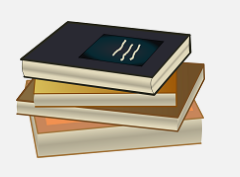

## Code
Berikut adalah fungsi-fungsi yang dibutuhkan untuk mengimplementasikan stacks.

In [1]:
def stack():
    s=[]
    return (s)
def push(s,data):
    s.append(data)
def pop(s):
    data=s.pop()
    return(data)
def peek(s):
    return(s[len(s)-1])
def isEmpty(s):
    return (s==[])
def size(s):
    return(len(s))

## Contoh Penggunaan Stack
stack dapat digunakan untuk memuat program dengan fungsi mengecek parentheses

In [8]:
def parenthesesCheck(p):
    s = stack()
    proses = ""
    error = []
    pasangan = {
        ')': '(',
        ']': '[',
        '}': '{'
    }
    perulangan = 0
    for i in p:
        if i in "([{":
            push(s, i)
            perulangan += 1
            proses += f"{perulangan}. Push stack with {i} --> {s}\n"
        elif i in ")]}":
            perulangan += 1
            if isEmpty(s):
                proses += f"{perulangan}. Pop Stack --> {s}\n"
                push(error, f"Kurung Tutup '{i}' tidak memiliki pasangan")
            else:
                top = pop(s)
                proses += f"{perulangan}. Pop Stack --> {s}\n"
                if top != pasangan[i]:
                    push(error, f"Kurung Buka '{top}' tidak cocok dengan kurung Tutup '{i}'")
    while not isEmpty(s):
        sisa = pop(s)
        push(error, f"Kurung Buka '{sisa}' tidak memiliki pasangan")
    check = error == []
    return check, proses, error

In [9]:
persamaan='([4+5]/{9+8]*(3+2]}'
check, proses, error = parenthesesCheck(persamaan)
print(check)
print('Proses Cek :')
print(proses)
print('Error :')
for i, e in enumerate(error,1):
    print(f"{i}. {e}")

False
Proses Cek :
1. Push stack with ( --> ['(']
2. Push stack with [ --> ['(', '[']
3. Pop Stack --> ['(']
4. Push stack with { --> ['(', '{']
5. Pop Stack --> ['(']
6. Push stack with ( --> ['(', '(']
7. Pop Stack --> ['(']
8. Pop Stack --> []

Error :
1. Kurung Buka '{' tidak cocok dengan kurung Tutup ']'
2. Kurung Buka '(' tidak cocok dengan kurung Tutup ']'
3. Kurung Buka '(' tidak cocok dengan kurung Tutup '}'


Konfersi infix ke postfix

In [10]:
def infix2Postfix(ekspresi):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2, '^': 3}
    s = stack()
    output = stack()
    outputstr = ''
    ekspresi = ekspresi.replace(" ", "")

    for i in ekspresi:
        if i.isalnum():
            push(output, i)

        elif i == '(':
            push(s, i)

        elif i == ')':
            while not isEmpty(s) and peek(s) != '(':
                push(output, pop(s))
            if not isEmpty(s) and peek(s) == '(':
                pop(s)
        else:
            while (not isEmpty(s) and peek(s) != '(' and precedence.get(peek(s), 0) >= precedence.get(i, 0)):
                push(output, pop(s))
            push(s, i)

    while not isEmpty(s):
        push(output, pop(s))

    for i in output:
        outputstr += str(i)
    return outputstr

In [11]:
ekspresiInfix = "A * B + ( C - D ) ^ F"
hasilPostfix = infix2Postfix(ekspresiInfix)

print(f"Ekspresi Infix   : {ekspresiInfix}")
print(f"Ekspresi Postfix : {hasilPostfix}")

Ekspresi Infix   : A * B + ( C - D ) ^ F
Ekspresi Postfix : AB*CD-F^+


# Definisi Queues
Queues atau antrian merupakan struktur data dimana penambahan data baru dan penghapusan
data berada di ujung yang berbeda. Hal ini berbeda dengan stacks, dimana penambahan data
baru dan penghapusan data, dilakukan pada ujung yang sama. <br> <br>
Pada Queues, seperti halnya antrian, penambahan data baru dilakukan di suatu ujung atau yang
dikenal dengan nama rear, dan penghapusan data dilakukan pada ujung yang dikenal dengan
nama front, seperti yang terlihat pada Gambar 1 berikut :

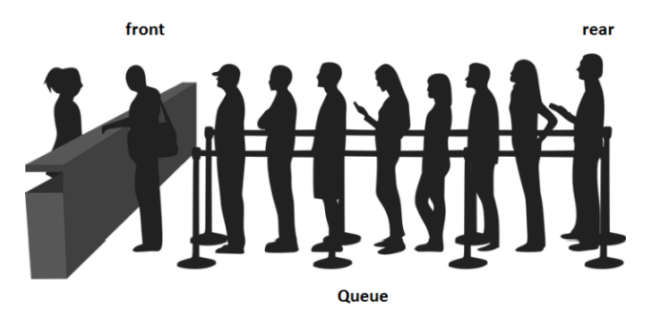

## Code
Berikut adalah code-code untuk pembentukan queues dan operasi-operasi yang terdapat pada
queues

In [16]:
def queue():
    q = []
    return q
def enqueue(q,data): #rear - indeks 0
    q.append(data)
    return (q)
def dequeue(q): #front - indeks terakhir
    data = q.pop(0)
    return (data)
# def isEmpty(q):
#     return (q==[])

## Contoh Penggunaan Queue
Permainan hot potato

In [15]:
def hotPotatoGame(n, k):
    # pemain
    jumlahPemain = n
    p = queue()
    for i in range(1, n+1):
        enqueue(p, i)

    while jumlahPemain > 1:
        for i in range(k-1):
            temp = dequeue(p)
            enqueue(p, temp)

        jumlahPemain -= 1
        dequeue(p)
    return dequeue(p)

In [17]:
print(hotPotatoGame(5, 2))

3


# Definisi Deque
Jika pada stacks, penambahan data baru dan
penghapusan dilakukan pada ujung yang sama, yaitu top, sedangkan pada queues, penambahan
data baru dan penghapusan dilakukan pada ujung yang berbeda, yaitu rear(penambahan data)
dan front(penghapusan data). Maka struktur data deques dapat dilakukan di kedua ujung, seperti
halnya queues, hanya terdapat sedikit perbedaan. <br> <br>
penambahan data dapat dilakukan pada kedua ujung, baik front maupun rear. Begitu juga halnya
dengan penghapusan data yang dapat dilakukan pada front maupun rear.


## Code
Operasi-operasi yang terdapat pada Deques antara lain :

In [20]:
def createDeque():
    d = []
    return d
def addFront(d, data):
    d.insert(0, data)
    return d
def addRear(d, data):
    d.append(data)
    return d
def removeRear(d):
    data = d.pop()
    return data
def removeFront(d):
    data = d.pop(0)
    return data
# def isEmpty(d):
#     return (d == [])

## Contoh Penggunaan Deque
Melakukan cek teks palindrom

In [21]:
def cekPalindrom(string):
    palindrom = createDeque()

    for huruf in string:
        addRear(palindrom, huruf)

    cek = True

    while size(palindrom) > 1:
        a = removeRear(palindrom)
        b = removeFront(palindrom)

        if a == b:
            cek = cek and True
        else:
            cek = cek and False

    return cek

In [22]:
print(cekPalindrom('hannah'))
print(cekPalindrom('surabaya'))
print(cekPalindrom('abcdcba'))
print(cekPalindrom('katak'))
print(cekPalindrom('taat'))
print(cekPalindrom('dia'))

True
False
True
True
True
False
